# Pango + Cairo Text Rendering

Small reusable version of the text renderer. It loads fonts from this project's `static/fonts` folder, renders shaped multilingual text with Pango/Cairo, and saves the result as a PNG.


In [1]:
import os
import subprocess
from pathlib import Path

PROJECT_ROOT = Path('/home/akhil/Invitation_research')
FONT_DIR = PROJECT_ROOT / 'static' / 'fonts'
OUTPUT_DIR = PROJECT_ROOT / 'z_research'
FONTCONFIG_FILE = Path('/tmp/invitation-fontconfig.xml')
FONTCONFIG_CACHE = Path('/tmp/fontconfig-cache')
FONTCONFIG_CACHE.mkdir(exist_ok=True)

gujarati_font = FONT_DIR / 'AnekGujarati_Expanded-Regular.ttf'
english_font = FONT_DIR / 'GreatVibes-Regular.ttf'

fontconfig_xml = f"""<?xml version="1.0"?>
<!DOCTYPE fontconfig SYSTEM "fonts.dtd">
<fontconfig>
  <include ignore_missing="yes">/etc/fonts/fonts.conf</include>
  <dir>{FONT_DIR}</dir>
  <cachedir>{FONTCONFIG_CACHE}</cachedir>
</fontconfig>
"""
FONTCONFIG_FILE.write_text(fontconfig_xml)
os.environ['FONTCONFIG_FILE'] = str(FONTCONFIG_FILE)

subprocess.run(
    ['fc-cache', '-f', str(FONT_DIR)],
    check=False,
    stdout=subprocess.DEVNULL,
    stderr=subprocess.DEVNULL,
)

import cairo
import gi
from PIL import Image, ImageFont
from IPython.display import display

gi.require_version('Pango', '1.0')
gi.require_version('PangoCairo', '1.0')
from gi.repository import Pango, PangoCairo

print(f'Using fonts from: {FONT_DIR}')


Using fonts from: /home/akhil/Invitation_research/static/fonts


In [2]:
def font_family(font_file: str | Path) -> str:
    return ImageFont.truetype(str(font_file), size=16).getname()[0]


def rgb(hex_color: str) -> tuple[float, float, float]:
    value = hex_color.lstrip('#')
    return tuple(int(value[i:i + 2], 16) / 255 for i in (0, 2, 4))


def pango_layout(ctx, text: str, family: str, size: int, max_width: int | None = None, align: str = 'left'):
    layout = PangoCairo.create_layout(ctx)
    layout.set_text(text, -1)

    desc = Pango.FontDescription()
    desc.set_family(family)
    desc.set_size(size * Pango.SCALE)
    layout.set_font_description(desc)

    if max_width:
        layout.set_width(max_width * Pango.SCALE)
        layout.set_wrap(Pango.WrapMode.WORD_CHAR)

    layout.set_alignment({
        'left': Pango.Alignment.LEFT,
        'center': Pango.Alignment.CENTER,
        'right': Pango.Alignment.RIGHT,
    }.get(align, Pango.Alignment.LEFT))
    layout.set_auto_dir(True)
    return layout


def render_text_layers_png(
    layers: list[dict],
    output: str | Path,
    canvas_size: tuple[int, int] = (800, 600),
):
    width, height = canvas_size
    surface = cairo.ImageSurface(cairo.FORMAT_ARGB32, width, height)
    # FORMAT_ARGB32 initialises to all-zero (fully transparent) — no paint needed
    ctx = cairo.Context(surface)

    for layer in layers:
        text = layer["text"]
        font_file = layer["font_file"]
        family = font_family(font_file)
        size = layer.get("size", 48)
        color = layer.get("color", "#111111")
        x = layer.get("x", 0)
        y = layer.get("y", 0)
        max_width = layer.get("max_width")
        align = layer.get("align", "left")

        layout = pango_layout(ctx, text, family, size, max_width, align)

        ctx.set_source_rgba(*rgb(color), 1)
        ctx.move_to(x, y)
        PangoCairo.show_layout(ctx, layout)

    output = Path(output)
    surface.write_to_png(str(output))
    return output


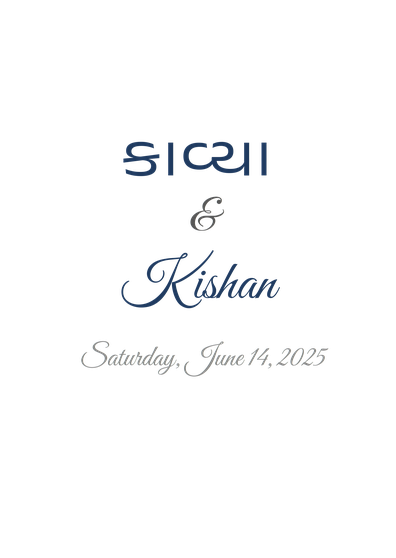

HQ base: invitation_hq.png  (2224x3132)  coord_scale=5.616
Saved: /home/akhil/Invitation_research/z_research/invitation_zoom_out.mp4  (618x808)


In [4]:
# ── Invitation config ──────────────────────────────────────────────────────────
invitation = {
    "canvas_size": (396, 558),
    "layers": [
        {
            "text": "કાવ્યા",
            "font_file": gujarati_font,
            "size": 42,
            "color": "#1f3a5f",
            "x": 120,
            "y": 120,
            "align": "left",
        },
        {
            "text": "&",
            "font_file": english_font,
            "size": 34,
            "color": "#555555",
            "x": 190,
            "y": 190,
        },
        {
            "text": "Kishan",
            "font_file": english_font,
            "size": 42,
            "color": "#1f3a5f",
            "x": 120,
            "y": 250,
        },
        {
            "text": "Saturday, June 14, 2025",
            "font_file": english_font,
            "size": 22,
            "color": "#888888",
            "x": 80,
            "y": 340,
            "align": "left",
        },
    ],
}

# ── Animation / video parameters (needed before HQ render) ────────────────────
quality_scale = 4
canvas_w, canvas_h = invitation["canvas_size"]

fps         = 60
duration    = 1
frames      = fps * duration
scale_start = 0.90
scale_end   = 0.55
padding_x, padding_y = 400, 500

final_w = round(canvas_w * scale_end)
final_h = round(canvas_h * scale_end)
video_w = final_w + padding_x
video_h = final_h + padding_y
video_w += video_w % 2
video_h += video_h % 2

render_w = video_w * quality_scale
render_h = video_h * quality_scale

# ── HQ base: render at the LARGEST size the animation will ever need ───────────
# At scale_start (first frame) img_w = round(video_w * scale_start) * quality_scale.
# The base must be >= that so every frame is a downscale (never an upscale).
max_disp_w = round(video_w * scale_start)
max_disp_h = round(max_disp_w * canvas_h / canvas_w)
hq_w = max_disp_w * quality_scale
hq_h = max_disp_h * quality_scale
hq_canvas = (hq_w, hq_h)

coord_scale = hq_w / canvas_w
hq_layers = []
for layer in invitation["layers"]:
    hq_layer = {
        **layer,
        "x":    round(layer["x"]    * coord_scale),
        "y":    round(layer["y"]    * coord_scale),
        "size": round(layer["size"] * coord_scale),
    }
    if layer.get("max_width"):
        hq_layer["max_width"] = round(layer["max_width"] * coord_scale)
    hq_layers.append(hq_layer)

hq_base_path = OUTPUT_DIR / "invitation_hq.png"
render_text_layers_png(hq_layers, hq_base_path, canvas_size=hq_canvas)

preview = Image.open(hq_base_path).resize(invitation["canvas_size"], Image.Resampling.LANCZOS)
display(preview)
print(f"HQ base: {hq_base_path.name}  ({hq_w}x{hq_h})  coord_scale={coord_scale:.3f}")

# ── Zoom-out animation → MP4 ──────────────────────────────────────────────────
base_image = Image.open(hq_base_path).convert("RGBA")

video_path = OUTPUT_DIR / "invitation_zoom_out.mp4"

cmd = [
    "ffmpeg", "-y",
    "-framerate", str(fps),
    "-f", "image2pipe",
    "-vcodec", "png",
    "-i", "-",
    "-c:v", "libx264",
    "-crf", "14",
    "-preset", "slow",
    "-vf", "format=yuv420p",
    "-movflags", "+faststart",
    str(video_path),
]

process = subprocess.Popen(cmd, stdin=subprocess.PIPE, stderr=subprocess.PIPE)

for frame in range(frames):
    progress = frame / max(frames - 1, 1)
    t = 1 - (1 - progress) ** 3
    scale = scale_start + (scale_end - scale_start) * t

    disp_w = round(video_w * scale)
    disp_h = round(disp_w * canvas_h / canvas_w)
    img_w  = disp_w * quality_scale
    img_h  = disp_h * quality_scale

    # base_image is always >= img size → pure downscale, always sharp
    scaled = base_image.resize((img_w, img_h), Image.Resampling.LANCZOS)

    # composite onto black background before encoding (H.264 has no alpha)
    bg = Image.new("RGB", (render_w, render_h), (0, 0, 0))
    x = (render_w - img_w) // 2
    y = (render_h - img_h) // 2
    bg.paste(scaled, (x, y), scaled)

    frame_img = bg.resize((video_w, video_h), Image.Resampling.LANCZOS)
    frame_img.save(process.stdin, format="PNG")

process.stdin.close()
stderr = process.stderr.read().decode()
if process.wait() != 0:
    print(stderr)
    raise RuntimeError("FFmpeg failed")

print(f"Saved: {video_path}  ({video_w}x{video_h})")


ext sharpness is fixed — the Gujarati letters are crisp now. The remaining issue is the black background, which exists because MP4/H.264 has no alpha channel, so we had to fill with black.

You have two options depending on what you want to do with this video:

Option A — Solid color background (simplest)
If you want a white, cream, or any specific background color, just change this line in the frame loop:


bg = Image.new("RGB", (render_w, render_h), (0, 0, 0))
# e.g. white:
bg = Image.new("RGB", (render_w, render_h), (255, 255, 255))
# or cream:
bg = Image.new("RGB", (render_w, render_h), (253, 245, 230))

Option B — Composite over a background video/image
If the text is meant to animate on top of another video (like a floral background), we composite in FFmpeg instead of Python. You'd keep the black background and use a chroma-key or just overlay the text layer over the background during a final render step.

Which one do you want? Tell me the background color or share the background video/image, and I'll update the cell